### Imports and Constants

In [2]:
import numpy as np
import pandas as pd
import random
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, classification_report, confusion_matrix, roc_auc_score, brier_score_loss, fbeta_score, make_scorer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder

from gensim.models import Word2Vec

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Unai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Unai\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Data Loading and splitting
Data is loaded from a csv file and split into training and testing sets using a 80/20 stratified split. The "susp" and "src" labels are changed to 1 and 0 respectively.

In [3]:
df = pd.read_csv("../data/reduced_dataset.csv")

print(df['clase'].value_counts())

X = df['texto']
y = df['clase'] == 'susp'

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=SEED
)


clase
susp    1929
src     1891
Name: count, dtype: int64


### Preprocessing
The following preprocessing steps are applied to the text: 
- All the text is lowercased. 
- All the characters in the text that are not letters are removed.
- The text is split into tokens/words.
- Stop words are removed.
- The words are lemmatized.
- The words are stemmed.

In [4]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

X_train_clean = X_train.apply(clean_text)
X_test_clean = X_test.apply(clean_text)


### Validation Strategy
A 5-fold cross-validation strategy is used for model validation. Shuffle the data before splitting it into folds to ensure that the distribution of the target variable is similar across folds. Random seed is set to 42 for reproducibility.

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

### Scoring Function
The scoring function defined in the paper is implemented.

The function consits on:
$$ \text{Score} = \frac{1}{5} \left( \text{AUC} + (1 - \text{Brier}) + \text{F}_1 + \text{F}_{0.5u} + \text{c@1} \right) $$

Then the custom_scorer is created to be used in the GridSearchCV.

In [6]:
def c_at_1(y_true, y_prob, threshold=0.5, uncertain_band=0.05):
    y_pred = np.full_like(y_true, -1)

    uncertain = np.abs(y_prob - threshold) <= uncertain_band
    y_pred[~uncertain] = (y_prob[~uncertain] >= threshold).astype(int)

    n = len(y_true)
    n_correct = np.sum(y_pred == y_true)
    n_unanswered = np.sum(uncertain)

    return (1/n) * (n_correct + n_unanswered * (n_correct/n))

In [7]:
def composite_metric(y_true, y_prob, **kwargs):
    y_prob = np.array(y_prob, dtype=float)

    if y_prob.ndim == 2:
        y_prob = y_prob[:, 1]

    y_pred = (y_prob >= 0.5).astype(int)

    roc = roc_auc_score(y_true, y_prob)
    brier = 1 - brier_score_loss(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    f05u = fbeta_score(y_true, y_pred, beta=0.5)
    c1 = c_at_1(y_true, y_prob)

    return np.mean([roc, brier, f1, f05u, c1])


custom_scorer = make_scorer(
    composite_metric,
    needs_proba=True,
    greater_is_better=True
)

### TF-IDF Unigrams
TF-IDF Vectorizer with Unigrams are evaluated using grid search.

In [8]:
pipeline_uni = Pipeline([
    ("tfidf", TfidfVectorizer(ngram_range=(1,1))),
    ("clf", LogisticRegression(max_iter=1000, random_state=SEED))
])

param_grid = {
    "clf__C": [0.01, 0.1, 1]
}

grid_uni = GridSearchCV(
    pipeline_uni,
    param_grid,
    cv=skf,
    scoring=custom_scorer,
)

grid_uni.fit(X_train_clean, y_train)

print("Best Unigram Score:", grid_uni.best_score_)


Best Unigram Score: 0.8451374577224902


### TF-IDF Bigrams
TF-IDF Vectorizer with Bigrams are evaluated using grid search. We wanted to try with 3-grams but it was not possible to run it in time as the execution time grows exponentially.

In [9]:
pipeline_bi = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1,2),
        max_features=5000, 
        min_df=3,       
        max_df=0.9  
    )),
    ("clf", LogisticRegression(max_iter=1000, solver="saga", random_state=SEED))
])

grid_bi = GridSearchCV(
    pipeline_bi,
    param_grid,
    cv=skf,
    scoring=custom_scorer,
)

grid_bi.fit(X_train_clean, y_train)

print("Best N-gram(1,2) Score:", grid_bi.best_score_)


Best N-gram(1,2) Score: 0.8621500009773871


### Word2Vec
Word2Vec tokenizer is used and grid search is performed again.

In [10]:
tokenized = [text.split() for text in X_train_clean]

w2v_model = Word2Vec(
    sentences=tokenized,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=SEED
)


In [11]:
class W2VVectorizer(BaseEstimator, TransformerMixin):
    def __init__(self, model):
        self.model = model
        self.dim = model.vector_size

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        vectors = []
        for text in X:
            words = text.split()
            word_vecs = [self.model.wv[w] for w in words if w in self.model.wv]
            if len(word_vecs) == 0:
                vectors.append(np.zeros(self.dim))
            else:
                vectors.append(np.mean(word_vecs, axis=0))
        return np.array(vectors)


In [12]:
w2v_vectorizer = W2VVectorizer(w2v_model)

X_train_w2v = w2v_vectorizer.transform(X_train_clean)
X_test_w2v = w2v_vectorizer.transform(X_test_clean)

clf = LogisticRegression(max_iter=1000, random_state=SEED)

param_grid = {
    "C": [0.01, 0.1, 1, 10]
}

grid_w2v = GridSearchCV(
    clf,
    param_grid,
    cv=skf,
    scoring=custom_scorer,
    n_jobs=-1
)

grid_w2v.fit(X_train_w2v, y_train)

print("Best W2V Score:", grid_w2v.best_score_)


Best W2V Score: 0.8815444357160807


### TF-IDF on Test
Best TF-IDF model is tested on the test.

In [13]:
best_sparse = grid_bi.best_estimator_
y_pred_sparse = best_sparse.predict(X_test_clean)

print("Sparse Test Score:",
      composite_metric(y_test, y_pred_sparse, average="macro"))


Sparse Test Score: 0.8563339221391588


### Word2Vec on Test
Best Word2Vec model is tested on the test.

In [14]:
best_w2v = grid_w2v.best_estimator_
y_pred_w2v = best_w2v.predict(X_test_w2v)

print("Dense Test Score:",
      composite_metric(y_test, y_pred_w2v, average="macro"))


Dense Test Score: 0.9032996562100722


### Best Model CM
Confusion Matrix for the best model (w2v)

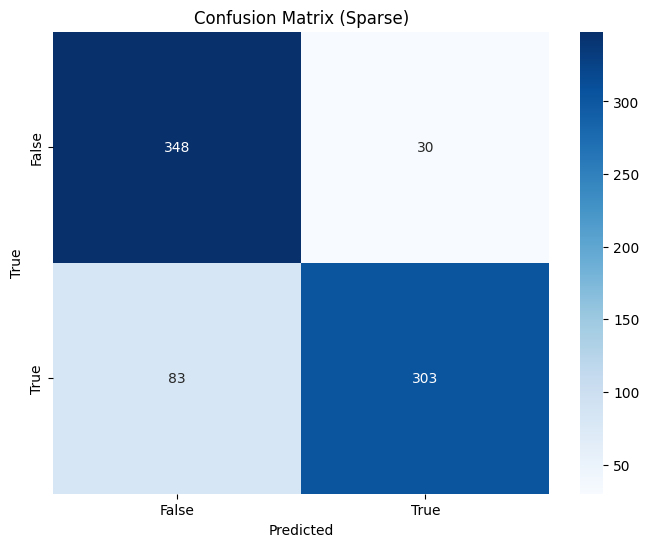

In [15]:
cm = confusion_matrix(y_test, y_pred_sparse)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=np.unique(y),
            yticklabels=np.unique(y),
            cmap='Blues'),
        
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Sparse)")
plt.show()


### Top Features per Class
The top 10 features for each class.

In [16]:
vectorizer = best_sparse.named_steps["tfidf"]
clf = best_sparse.named_steps["clf"]

feature_names = vectorizer.get_feature_names_out()
coefs = clf.coef_[0]

top10_pos = np.argsort(coefs)[-10:]
print(f"\nTop features for class {clf.classes_[1]}:")
print([feature_names[j] for j in top10_pos])

top10_neg = np.argsort(coefs)[:10]
print(f"\nTop features for class {clf.classes_[0]}:")
print([feature_names[j] for j in top10_neg])



Top features for class True:
['geq', 'expressed', 'thereby', 'leq', 'equation', 'additionally', 'exhibit', 'within', 'notably', 'quad']

Top features for class False:
['displaystyle', 'show', 'see', 'ie', 'hence', 'use', 'therefore', 'different', 'used', 'fig']


### 5 Missclassification examples

In [17]:
errors = pd.DataFrame({
    "text": X_test,
    "true": y_test,
    "pred": y_pred_sparse
})

misclassified = errors[errors["true"] != errors["pred"]]

print(misclassified.head(5))


                                                   text  true   pred
914   Constraining nuclear star cluster formation us...  True  False
1640  Multi-Core Processor Scheduling with Respect t...  True  False
750   Critical behavior of density of states near Fe...  True  False
520   Hide it to see it better: a robust setup to pr...  True  False
821   A Bi-Encoder LSTM Model For Learning Unstructu...  True  False
